In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


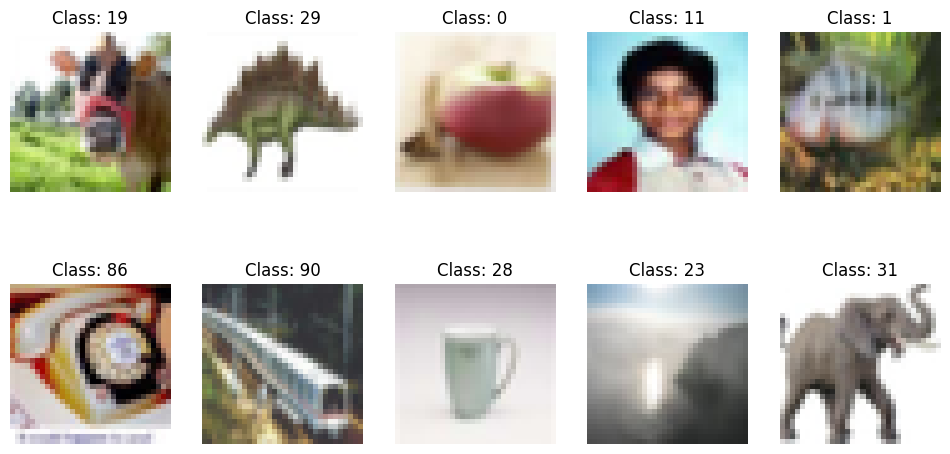

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(f"Class: {y_train[i][0]}")
    plt.axis('off')

plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

In [ ]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3),
                 activation='relu',
                 padding='same',
                 input_shape=(32,32,3)))

model.add(Conv2D(32, (3,3),
                 activation='relu',
                 padding='same'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Second Convolution Block
model.add(Conv2D(64, (3,3),
                 activation='relu',
                 padding='same'))

model.add(Conv2D(64, (3,3),
                 activation='relu',
                 padding='same'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(100, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,214,532 (8.45 MB)

 Trainable params: 2,214,532 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.0708 - loss: 4.0895 - val_accuracy: 0.1700 - val_loss: 3.5237
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1768 - loss: 3.4406 - val_accuracy: 0.2505 - val_loss: 3.1068
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2443 - loss: 3.0889 - val_accuracy: 0.2952 - val_loss: 2.8514
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2879 - loss: 2.8469 - val_accuracy: 0.3423 - val_loss: 2.6377
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3221 - loss: 2.6596 - val_accuracy: 0.3570 - val_loss: 2.5238
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3533 - loss: 2.5079 - val_accuracy: 0.3803 - val_loss: 2.4591
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3765 - loss: 2.3841 - val_accuracy: 0.3957 - val_loss: 2.3750
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4009 - loss: 2.2755 - val_accuracy: 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4390 - loss: 2.2628
Test Loss : 2.262751817703247
Test Accuracy : 0.4390000104904175


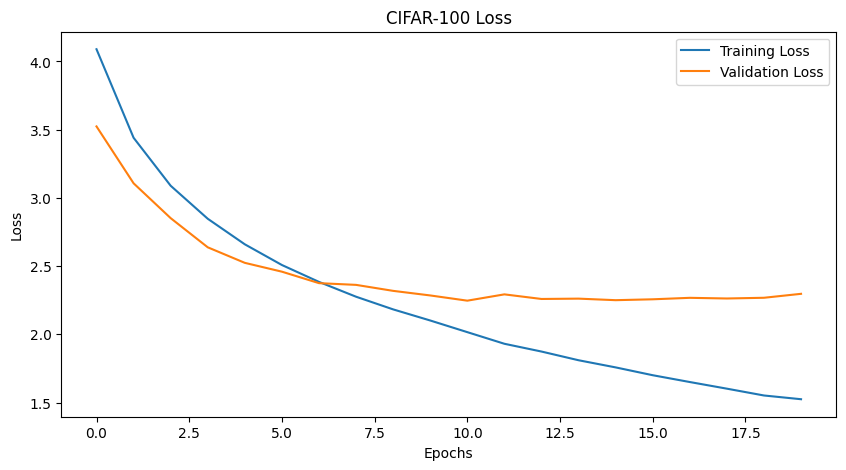

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-100 Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


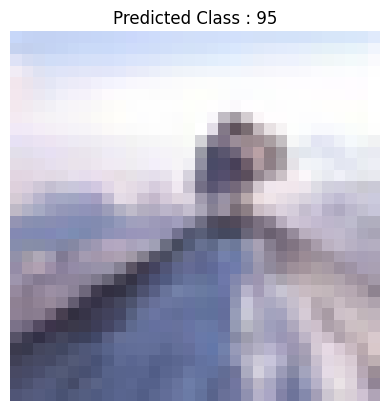

In [ ]:
sample = X_test[0]

prediction = model.predict(
    sample.reshape(1,32,32,3)
)

predicted_class = np.argmax(prediction)

plt.imshow(sample)
plt.title(f"Predicted Class : {predicted_class}")
plt.axis('off')
plt.show()

Saving Screenshot 2026-06-05 184434.png to Screenshot 2026-06-05 184434.png


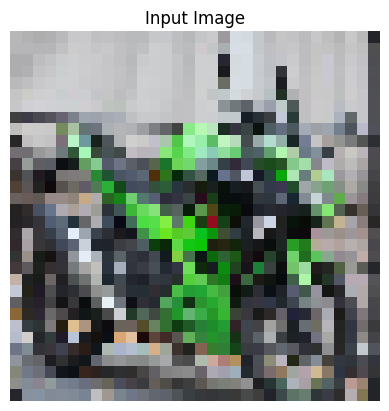

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Class: motorcycle
Confidence: 98.33663 %


In [ ]:
from google.colab import files
import cv2

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img = cv2.resize(img, (32,32))

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

img = img / 255.0

img_input = img.reshape(1,32,32,3)

prediction = model.predict(img_input)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("Predicted Class:",
      class_names[predicted_class])

print("Confidence:",
      confidence,"%")
